In [1]:
#usar 5 tickets
#trabajar 15 años historicos
#portafolio=1000000 dlls
#estimar a 20 días 
#hacer 10000 simulaciones

import yfinance as yf #datos de yahoo finance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from scipy.stats import norm #conseguir una distribucion normal

In [2]:
#datos historicos para el rango de 15 años
years = 15
endDate = dt.datetime.now()
print(endDate)
startDate = endDate - dt.timedelta(days=365*years)
print(startDate)

2026-02-19 00:04:37.973168
2011-02-23 00:04:37.973168


In [3]:
#tickers a usar compañia/empresa
tickers = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [4]:
#descargar los precios ajustados de cierre
adj_close_df=pd.DataFrame()
for ticker in tickers:
    data=yf.download(ticker,start=startDate,end=endDate,auto_adjust=False)
    adj_close_df[ticker]=data['Adj Close']
print(adj_close_df)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                   SPY        BND         GLD         QQQ         VTI
Date                                                                 
2011-02-23  100.229935  52.049706  137.509995   49.610321   51.880642
2011-02-24  100.161057  52.101757  136.479996   49.873474   51.888340
2011-02-25  101.232056  52.245010  137.380005   50.566406   52.541821
2011-02-28  101.859352  52.316631  137.660004   50.671638   52.826302
2011-03-01  100.161057  52.291817  140.029999   49.855923   51.934467
...                ...        ...         ...         ...         ...
2026-02-11  691.960022  74.320000  467.630005  613.109985  341.470001
2026-02-12  681.270020  74.660004  451.390015  600.640015  336.010010
2026-02-13  681.750000  74.879997  462.619995  601.919983  336.649994
2026-02-17  682.849976  74.870003  448.200012  601.299988  337.070007
2026-02-18  686.289978  74.790001  458.279999  605.789978  338.829987

[3769 rows x 5 columns]


In [5]:
#calcuar lso retornos diarios
log_returns = np.log(adj_close_df / adj_close_df.shift(1))
log_returns = log_returns.dropna()
print(log_returns)

                 SPY       BND       GLD       QQQ       VTI
Date                                                        
2011-02-24 -0.000687  0.001000 -0.007519  0.005290  0.000148
2011-02-25  0.010636  0.002746  0.006573  0.013798  0.012515
2011-02-28  0.006177  0.001370  0.002036  0.002079  0.005400
2011-03-01 -0.016814 -0.000474  0.017070 -0.016229 -0.017027
2011-03-02  0.002136 -0.001999 -0.000786  0.005264  0.002070
...              ...       ...       ...       ...       ...
2026-02-11 -0.000231 -0.002016  0.011247  0.002678 -0.000966
2026-02-12 -0.015569  0.004564 -0.035346 -0.020549 -0.016119
2026-02-13  0.000704  0.002942  0.024574  0.002129  0.001903
2026-02-17  0.001612 -0.000133 -0.031666 -0.001031  0.001247
2026-02-18  0.005025 -0.001069  0.022241  0.007439  0.005208

[3768 rows x 5 columns]


In [6]:
#calcular la rentabilidad esperada de una cartera 
def expected_returns(weights, log_returns):
    return np.sum(weights * log_returns.mean())

In [7]:
#calcular la desviacion estandar
def standard_deviation(weights , cov_matrix):
    variance=weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

In [8]:
#definir la covarianza de los retornos
#captura como se mueve los activos entre si y es esencial para la varianza de la cartera
cov_matrix = log_returns.cov()
print(cov_matrix)

          SPY       BND       GLD       QQQ       VTI
SPY  0.000118  0.000001  0.000005  0.000132  0.000120
BND  0.000001  0.000010  0.000009  0.000002  0.000001
GLD  0.000005  0.000009  0.000106  0.000007  0.000006
QQQ  0.000132  0.000002  0.000007  0.000171  0.000135
VTI  0.000120  0.000001  0.000006  0.000135  0.000123


In [9]:
#calcular la rentabilidad esperada y desviacion estandar de una cartera(portafolio)
portfolio_value = 1000000
weights = np.array([1/len(tickers)] * len(tickers))  
print([1/len(tickers)],len([tickers]))
print(weights)

portfolio_expected_return = expected_returns(weights, log_returns)
portfolio_std_dev = standard_deviation(weights, cov_matrix)
print(portfolio_expected_return)
print(portfolio_std_dev)

[0.2] 1
[0.2 0.2 0.2 0.2 0.2]
0.0004176745941045075
0.007380170836954457


In [10]:
#definicion del metodo de montecarlo
#normal (0,1) 0 indica la media y el 1 las desviaciones estandar -3 a 3
def random_z_score():
    return np.random.normal(0, 1)

In [11]:
#crear escenario de perdida y ganancia
days = 20
def scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days):
    return portfolio_value * portfolio_expected_return * days + portfolio_value * portfolio_std_dev * z_score * np.sqrt(days)

In [12]:
#simulacion
simulations = 100000
scenario_return = []

for i in range(simulations):
    z_score = random_z_score()
    scenario_return.append(scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days))

In [13]:
#calculo del riesgo VaR
confidence_interval = 0.95
VaR = -np.percentile(scenario_return, 100 * (1 - confidence_interval))
print(VaR)

45884.647419357265


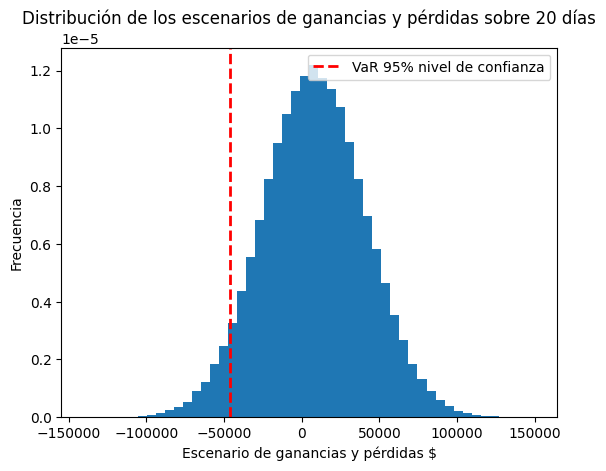

In [14]:
#Grafica
plt.hist(scenario_return, bins=50, density=True)
plt.xlabel('Escenario de ganancias y pérdidas $')
plt.ylabel('Frecuencia')
plt.title(f'Distribución de los escenarios de ganancias y pérdidas sobre {days} días')
plt.axvline(-VaR, color='red', linestyle='dashed', linewidth=2, label=f'VaR {confidence_interval:.0%} nivel de confianza')
plt.legend()
plt.show()

In [ ]:
#INTERPRETACION: Con un 95% de confianza, la perdida maxima en 20 días no excedera ese valor  (segun la simulación). 
#El VaR es una medida de riesgo ampliamente usada con limitaciones. Se puede utilizar otro tipo de distribucción como la t-student 
#que maneja mas desviaciones estandar y nos permitira ver mas riesgo, que es como realmente operan las finanzas.
SE REQUIERE UNA SIMULACIÓN PARA LA GENERACION DE CONTRASEÑAS PARA LA GENERACION DE CUENTAS PARA EL ACCESO AL SISTEMA X
LOS REQUISITOS SON: 
TAMANO=12
2 MAYUSCULAS
2 CARACTERES ESPECIALES
6 NUMEROS
2 MINUSCULAS
ESTOS SE DEBEN ALMACENAR EN LA BASE DE DATOS DE EDIFICIOS ESCOLARES EN UN CAMPO LLAMADO CONTRASEÑA